# Parte 04 - Segementación en BI

Variables RFM, agrega variables específicas del negocio (botica), clusters, perfiles y estrategías.

### Preparación del entorno

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


### Carga y visualización de los datos

In [16]:
DATA_DIR = '../data/processed'

# Verificar si estamos corriendo desde la carpeta raíz o dentro de notebooks
if not os.path.exists(DATA_DIR):
    DATA_DIR = 'data/processed' # Para poder correrlo desde la raíz

df_ventas = pd.read_csv(f"{DATA_DIR}/Fact_Ventas.csv", sep=";", encoding="utf-8")
df_clientes = pd.read_csv(f"{DATA_DIR}/Dim_Cliente.csv", sep=";", encoding="utf-8")
df_productos = pd.read_csv(f"{DATA_DIR}/Dim_Producto.csv", sep=";", encoding="utf-8")

# Convertir fecha a datetime
df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'])

print("Datos cargados correctamente.")

Datos cargados correctamente.


In [17]:
df_clientes.head(5)

,id_cliente,nombre,sexo,fecha_nacimiento,distrito,fecha_alta,segmento_programa,churn
0,1,Albano Llopis Hierro,M,1993-09-04,La Molina,2023-11-21,Bronce,0
1,2,Buenaventura Calatayud Bonet,M,1994-11-14,Chorrillos,2023-11-15,Bronce,0
2,3,Héctor Alcides Andrés Bueno,M,1939-04-25,San Borja,2023-07-27,Sin Programa,0
3,4,Demetrio Vazquez Amor,M,1969-01-23,Santiago de Surco,2023-02-10,Bronce,0
4,5,Chita Rivas-Giménez,F,1948-06-23,San Borja,2023-11-22,Sin Programa,0


In [18]:
df_productos.head(5)

,id_producto,nombre,categoria,subcategoria,marca,precio_lista,costo
0,1,Cetirizina 10mg,Medicamentos,Cardiovascular,Genérico,47.44,24.71
1,2,Gel de Ducha Aloe Vera,Cuidado Personal,Higiene Bucal,SaludTotal Labs,6.09,2.68
2,3,Limpiador Facial Espumoso,Dermocosmética,Antiedad,BienestarLab,89.85,61.37
3,4,Colágeno Hidrolizado,Suplementos y Vitaminas,Proteínas y Aminoácidos,BioSana,25.46,16.42
4,5,Pañales Talla G x26,Cuidado del Bebé,Accesorios Bebé,PharmaPlus,8.54,5.92


In [19]:
df_clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id_cliente         5000 non-null   int64
 1   nombre             5000 non-null   str  
 2   sexo               5000 non-null   str  
 3   fecha_nacimiento   5000 non-null   str  
 4   distrito           5000 non-null   str  
 5   fecha_alta         5000 non-null   str  
 6   segmento_programa  5000 non-null   str  
 7   churn              5000 non-null   int64
dtypes: int64(2), str(6)
memory usage: 312.6 KB


In [20]:
df_productos.describe()

,id_producto,precio_lista,costo
count,500.000000,500.000000,500.000000
mean,250.500000,60.698180,33.181720
std,144.481833,62.097266,34.459281
min,1.000000,2.460000,1.010000
25%,125.750000,21.347500,11.205000
50%,250.500000,38.585000,20.750000
75%,375.250000,76.430000,41.232500
max,500.000000,338.290000,186.070000


### Variables RFM

Construcción de las 3 variables RFM (Recencia, Frecuencia, Monto) y 2 variables adicionales para el negocio (botica):
- Afinidad a Promociones (% de gasto en ofertas)
- Afinidad a Medicamentos (% de gasto en la categoría Medicamentos)

In [21]:
# Unir ventas con categoría de producto para calcular afinidad a medicamentos
df_ventas = df_ventas.merge(df_productos[['id_producto', 'categoria']], on='id_producto', how='left')

# Normalizar la categoría a mayúsculas para evitar problemas
df_ventas['categoria'] = df_ventas['categoria'].str.strip().str.upper()

# Fecha actual para la Recencia (usamos la fecha máxima de las ventas como referencia)
fecha_referencia = df_ventas['fecha'].max()

# Variables a nivel de ticket/detalle
df_ventas['gasto_con_promo'] = np.where(df_ventas['descuento'] > 0, df_ventas['importe'], 0)
df_ventas['gasto_medicamentos'] = np.where(df_ventas['categoria'] == 'MEDICAMENTOS', df_ventas['importe'], 0)

# Agregación por cliente
rfm = df_ventas.groupby('id_cliente').agg(
    recencia=('fecha', lambda x: (fecha_referencia - x.max()).days),
    frecuencia=('id_venta', 'nunique'),
    monto=('importe', 'sum'),
    monto_promos=('gasto_con_promo', 'sum'),
    monto_medicamentos=('gasto_medicamentos', 'sum')
).reset_index()

# Cálculo de porcentajes de afinidad
rfm['afinidad_promociones'] = np.where(rfm['monto'] > 0, rfm['monto_promos'] / rfm['monto'], 0)
rfm['afinidad_medicamentos'] = np.where(rfm['monto'] > 0, rfm['monto_medicamentos'] / rfm['monto'], 0)

# Filtro de clientes que no compraron (monto = 0) o valores nulos
rfm = rfm[rfm['monto'] > 0].copy()

# Seleccionar solo las features finales para el modelo
features = ['recencia', 'frecuencia', 'monto', 'afinidad_promociones', 'afinidad_medicamentos']
X_raw = rfm[features]

print("Datos procesados:")
print(X_raw.head(10))

Datos procesados:
   recencia  frecuencia   monto  afinidad_promociones  afinidad_medicamentos
0       170           5  337.55              0.320841               0.000000
1       128           5  211.37              0.948905               0.247197
2       179           5  502.38              0.853099               0.011366
3       212           6  493.15              0.069573               0.053675
4       381           1  102.96              1.000000               0.000000
5       441           2  109.70              0.817046               0.000000
6       217           4  160.41              0.064210               0.000000
7       131           9  664.81              0.287601               0.000000
8       701           5  362.00              0.000000               0.000000
9       173           3  123.42              0.679468               0.000000


### Escalado de las variables

Para que algoritmos basados en distancias (K-Means) funcionen correctamente.

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
print(X_scaled[:5]) 

[[-0.28603637 -0.42192416 -0.43625843 -0.11065612 -0.5438578 ]
 [-0.48408342 -0.42192416 -0.52578339  1.7234232   0.99526005]
 [-0.24359771 -0.42192416 -0.31931121  1.44365063 -0.47309049]
 [-0.08798932 -0.36760375 -0.32585992 -0.84441295 -0.20965981]
 [ 0.7089143  -0.63920581 -0.60270051  1.87263221 -0.5438578 ]]


### Determinar el número de clusters con el método codo y el coeficiente de Silueta

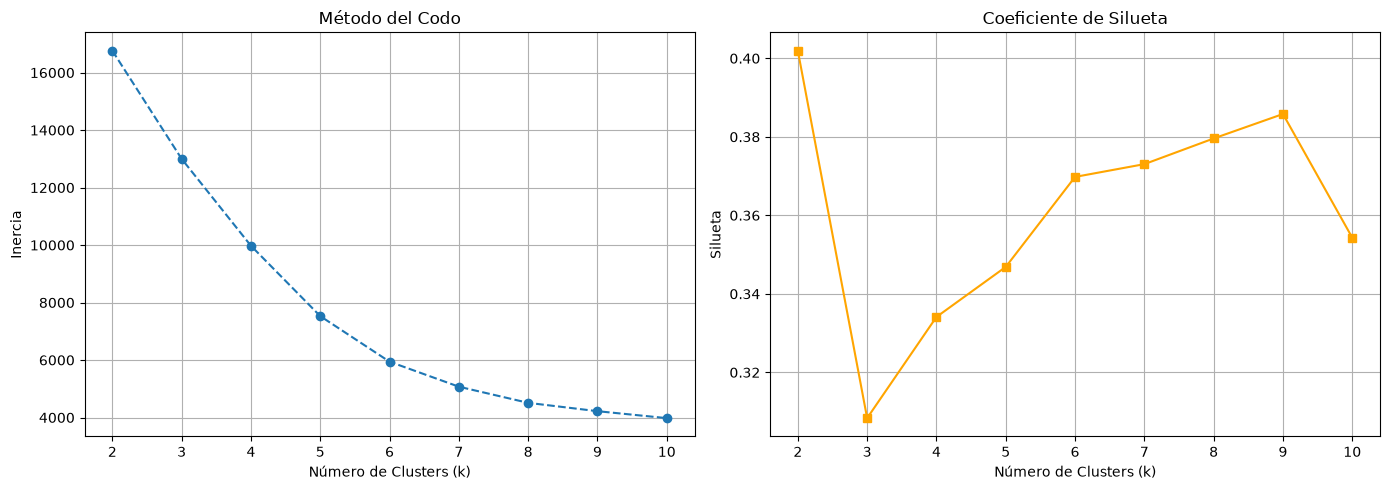

In [23]:
inercias = []
siluetas = []
rango_k = range(2, 11)

for k in rango_k:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_scaled, km.labels_))

# Visualización
plt.figure(figsize=(14, 5))

# Método del Codo
plt.subplot(1, 2, 1)
plt.plot(rango_k, inercias, marker='o', linestyle='--')
plt.title('Método del Codo')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.xticks(rango_k)
plt.grid(True)

# Coeficiente de Silueta
plt.subplot(1, 2, 2)
plt.plot(rango_k, siluetas, marker='s', color='orange', linestyle='-')
plt.title('Coeficiente de Silueta')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silueta')
plt.xticks(rango_k)
plt.grid(True)

plt.tight_layout()
plt.show()

### Ejecutar K-Means con el K elegido

El `k` elegido es 6 debido a que en el análisis del codo observamos una reducción continua, pero con el coeficiente de silueta vemos que en `k=6` se tiene una mejor cohesión superando a `k=4`. Por lo tanto, hemos seleccionado a `k=6` para descubrir micro-nichos del negocio.

In [24]:
k_optimo = 6 
modelo = KMeans(n_clusters=k_optimo, n_init=10, random_state=42)
rfm['cluster'] = modelo.fit_predict(X_scaled)

# Perfilamiento
perfil = rfm.groupby('cluster')[features].mean().round(2)
perfil['tamaño'] = rfm.groupby('cluster').size()
perfil['%_clientes'] = (perfil['tamaño'] / len(rfm) * 100).round(1)

print("\nPerfil promedio por cluster")
print(perfil)


Perfil promedio por cluster
         recencia  frecuencia    monto  afinidad_promociones  \
cluster                                                        
0          320.50        2.78   120.84                  0.30   
1          307.52        4.75   334.88                  0.86   
2           58.99       28.21  2133.10                  0.34   
3           99.91       79.36  5964.05                  0.32   
4          503.43        5.93   455.99                  0.13   
5          111.64        5.75   424.98                  0.14   

         afinidad_medicamentos  tamaño  %_clientes  
cluster                                             
0                         0.72     195         4.2  
1                         0.06    1126        24.1  
2                         0.07     770        16.5  
3                         0.07     232         5.0  
4                         0.05     864        18.5  
5                         0.06    1489        31.8  


### Etiquetado de segmentos

Según el perfilamiento manual del modelo, nombramos los segmentos e identificamos a qué grupo pertenece cada cluster.

#### Función heurística para nombrar los segmentos

In [25]:
def asignar_nombres_segmento(row):
    # Lógica robusta basada en las características absolutas observadas para 6 clusters:
    if row['afinidad_medicamentos'] > 0.5:
        return 'En Riesgo (Solo Medicamentos)'
    elif row['afinidad_promociones'] > 0.5:
        return 'Cazadores de Ofertas'
    elif row['frecuencia'] > 50:
        return 'Leales VIP / Crónicos'
    elif row['frecuencia'] > 15:
        return 'Frecuentes Regulares'
    elif row['recencia'] < 150:
        return 'Esporádicos Recientes'
    else:
        return 'Esporádicos / Desertores'

perfil['segmento_nombre'] = perfil.apply(asignar_nombres_segmento, axis=1)

# Mapeamos los nombres al dataset final
mapa_segmentos = perfil['segmento_nombre'].to_dict()
rfm['segmento'] = rfm['cluster'].map(mapa_segmentos)

print("\nNombres asignados")
print(perfil[['tamaño', '%_clientes', 'segmento_nombre']])


Nombres asignados
         tamaño  %_clientes                segmento_nombre
cluster                                                   
0           195         4.2  En Riesgo (Solo Medicamentos)
1          1126        24.1           Cazadores de Ofertas
2           770        16.5           Frecuentes Regulares
3           232         5.0          Leales VIP / Crónicos
4           864        18.5       Esporádicos / Desertores
5          1489        31.8          Esporádicos Recientes


#### Visualizar los segmentos

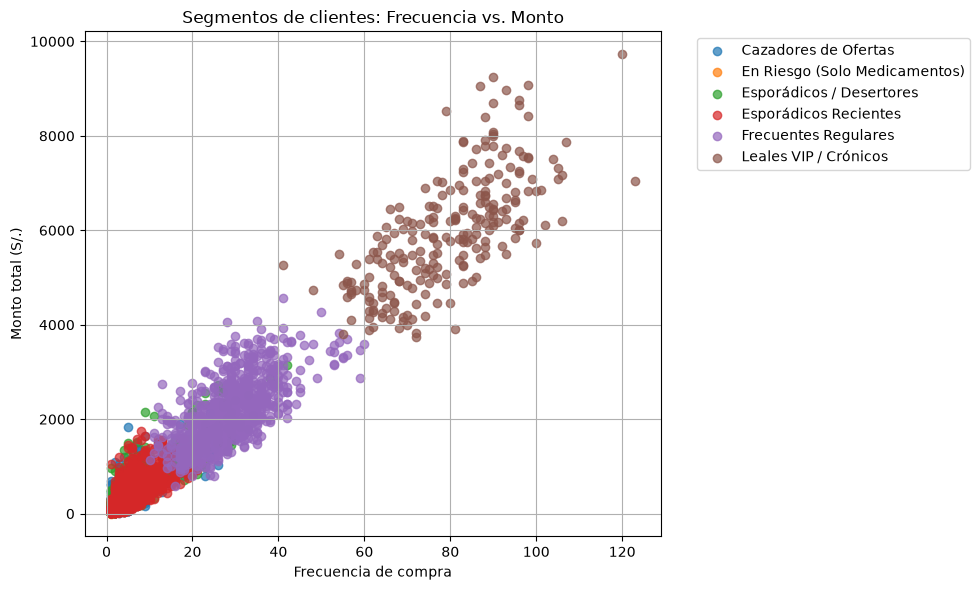

In [26]:
plt.figure(figsize=(10, 6)) 
for seg in sorted(rfm["segmento"].unique()):
    grupo = rfm[rfm["segmento"] == seg] 
    plt.scatter(grupo["frecuencia"], grupo["monto"], label=f"{seg}", alpha=0.7) 
plt.title("Segmentos de clientes: Frecuencia vs. Monto") 
plt.xlabel("Frecuencia de compra") 
plt.ylabel("Monto total (S/.)") 
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.grid(True)
plt.tight_layout()
plt.show()

#### Tabla de perfil de segmentos

In [27]:
tabla_perfil = perfil.copy()
tabla_perfil['Segmento'] = tabla_perfil['segmento_nombre']
tabla_perfil['Tamaño'] = tabla_perfil['tamaño'].apply(lambda x: f"{x:,}")
tabla_perfil['% del Total'] = tabla_perfil['%_clientes'].astype(str) + "%"
tabla_perfil['Recencia'] = tabla_perfil['recencia'].astype(int).astype(str) + " días"
tabla_perfil['Frecuencia'] = tabla_perfil['frecuencia'].round(1)
tabla_perfil['Monto Acumulado'] = tabla_perfil['monto'].apply(lambda x: f"S/ {x:,.0f}")
tabla_perfil['Afinidad Promos'] = (tabla_perfil['afinidad_promociones'] * 100).round(0).astype(int).astype(str) + "%"
tabla_perfil['Afinidad Medicamentos'] = (tabla_perfil['afinidad_medicamentos'] * 100).round(0).astype(int).astype(str) + "%"

columnas_mostrar = ['Segmento', 'Tamaño', '% del Total', 'Recencia', 'Frecuencia', 'Monto Acumulado', 'Afinidad Promos', 'Afinidad Medicamentos']
tabla_final = tabla_perfil[columnas_mostrar].set_index('Segmento')

tabla_final

,Tamaño,% del Total,Recencia,Frecuencia,Monto Acumulado,Afinidad Promos,Afinidad Medicamentos
Segmento,,,,,,,
En Riesgo (Solo Medicamentos),195,4.2%,320 días,2.8,S/ 121,30%,72%
Cazadores de Ofertas,"1,126",24.1%,307 días,4.8,S/ 335,86%,6%
Frecuentes Regulares,770,16.5%,58 días,28.2,"S/ 2,133",34%,7%
Leales VIP / Crónicos,232,5.0%,99 días,79.4,"S/ 5,964",32%,7%
Esporádicos / Desertores,864,18.5%,503 días,5.9,S/ 456,13%,5%
Esporádicos Recientes,"1,489",31.8%,111 días,5.8,S/ 425,14%,6%


#### Estrategias por segmento

- **Leales VIP / Crónicos:** Programa "AndesPlus Oro", delivery gratuito, resurtido automático.
- **Frecuentes Regulares:** Venta cruzada agresiva en punto de venta para subir el ticket promedio y pasarlos a VIP.
- **Cazadores de Ofertas:** Alertas por email/SMS exclusivamente en CyberDays o quincenas para rotar inventario.
- **Esporádicos Recientes:** Enviar cupón de "segunda compra" válido por 15 días para fomentar el hábito.
- **En Riesgo (Solo Medicamentos):** Tuvieron una urgencia médica hace tiempo. No gastar mucho marketing en ellos.
- **Esporádicos / Desertores:** Hace más de 1 año no compran. Purgar de la base de datos o enviar un último cupón super-agresivo.

### Exportación

In [28]:
# Seleccionamos las columnas para Power BI
columnas_exportacion = ['id_cliente', 'recencia', 'frecuencia', 'monto', 'afinidad_promociones', 'afinidad_medicamentos', 'segmento']
df_export = rfm[columnas_exportacion]

ruta_salida = f"{DATA_DIR}/segmentacion_clientes.csv"
df_export.to_csv(ruta_salida, sep=";", index=False, encoding="utf-8")
print("Exportación completada correctamente.")

Exportación completada correctamente.
